In [ ]:
# Install required packages (run once)
# !pip install numpy pandas matplotlib seaborn scikit-learn joblib astropy scipy tensorflow lightkurve shap streamlit tenacity --quiet

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [3]:
# ── Config ────────────────────────────────────────────────────────────
N_BINS     = 400
BATCH_SIZE = 16
EPOCHS     = 25

# ── Load pre-processed dataset ────────────────────────────────────────
data    = np.load('kepler_200_dataset.npz')
X_train = data['X_train']   # (2400, 400, 1) float32
X_test  = data['X_test']    # (600,  400, 1) float32
y_train = data['y_train']   # (2400,) int64
y_test  = data['y_test']    # (600,)  int64

# ── Stratified val split carved from train ────────────────────────────
# test_size = 0.15 / 0.80 keeps overall val ratio at ~15%
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15 / 0.80,
    stratify=y_train, random_state=42
)

# Class weights computed on training set only (no val contamination)
classes          = np.unique(y_train)
class_weights    = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

# Persist test split so app.py can load it without re-splitting
joblib.dump((X_test, y_test), 'test_split.pkl')

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Input shape: {X_train.shape[1:]}')
print(f'Class weights: {class_weight_dict}')
print(f'Label balance — train 1s: {y_train.mean():.2%} | test 1s: {y_test.mean():.2%}')


Train: 1950 | Val: 450 | Test: 600
Input shape: (400, 1)
Class weights: {0: 1.0, 1: 1.0}
Label balance — train 1s: 50.00% | test 1s: 50.00%


In [4]:
# 1D CNN Definition
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 9, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

model = build_cnn((N_BINS, 1))
model.summary()

2026-05-11 15:01:04.516433: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-11 15:01:04.516482: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-11 15:01:04.516491: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-11 15:01:04.516720: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-11 15:01:04.516735: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 400, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 400, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 200, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,145 (336.50 KB)

 Trainable params: 85,441 (333.75 KB)

 Non-trainable params: 704 (2.75 KB)

In [5]:
# Training with Callbacks
cb = [
    callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_cnn_kepler.keras', monitor='val_auc', save_best_only=True, mode='max')
]
# Fix: use explicit stratified val set instead of validation_split
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict, callbacks=cb, verbose=2
)


Epoch 1/25


2026-05-11 15:01:06.767221: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


122/122 - 15s - 123ms/step - accuracy: 0.4795 - auc: 0.4857 - loss: 0.6955 - val_accuracy: 0.5000 - val_auc: 0.4844 - val_loss: 0.7070 - learning_rate: 1.0000e-04
Epoch 2/25
122/122 - 5s - 38ms/step - accuracy: 0.5405 - auc: 0.5601 - loss: 0.6889 - val_accuracy: 0.5000 - val_auc: 0.5067 - val_loss: 0.7848 - learning_rate: 1.0000e-04
Epoch 3/25
122/122 - 4s - 36ms/step - accuracy: 0.5687 - auc: 0.5993 - loss: 0.6844 - val_accuracy: 0.5000 - val_auc: 0.5027 - val_loss: 0.9031 - learning_rate: 1.0000e-04
Epoch 4/25

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
122/122 - 5s - 38ms/step - accuracy: 0.5913 - auc: 0.6194 - loss: 0.6802 - val_accuracy: 0.5000 - val_auc: 0.5384 - val_loss: 0.9956 - learning_rate: 1.0000e-04
Epoch 5/25
122/122 - 5s - 37ms/step - accuracy: 0.6092 - auc: 0.6471 - loss: 0.6754 - val_accuracy: 0.5000 - val_auc: 0.5489 - val_loss: 0.7630 - learning_rate: 5.0000e-05
Epoch 6/25
122/122 - 4s - 36ms/step - accuracy: 0.6056 - auc: 0.6527 - l

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
                precision    recall  f1-score   support

False Positive       0.49      0.25      0.33       300
     Confirmed       0.50      0.74      0.60       300

      accuracy                           0.49       600
     macro avg       0.49      0.49      0.46       600
  weighted avg       0.49      0.49      0.46       600

ROC-AUC: 0.4726


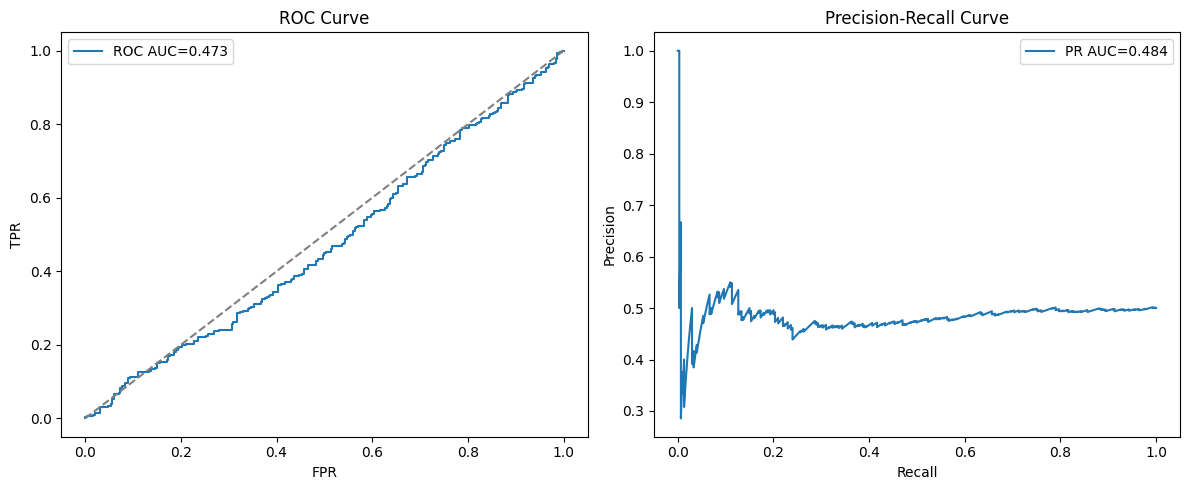

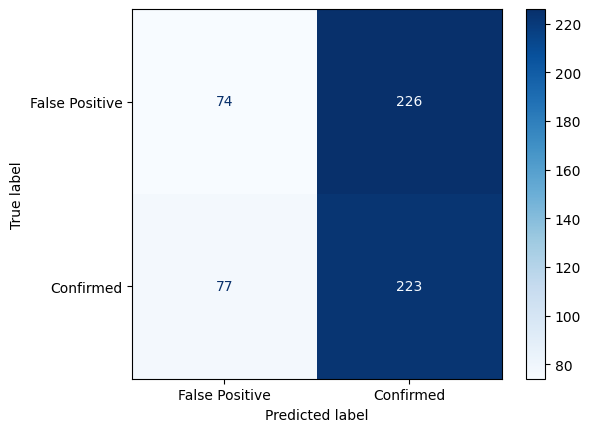

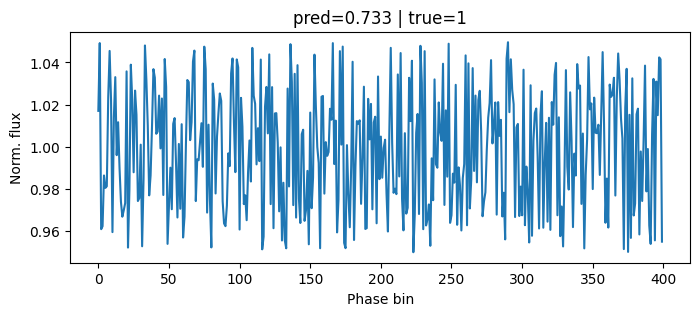

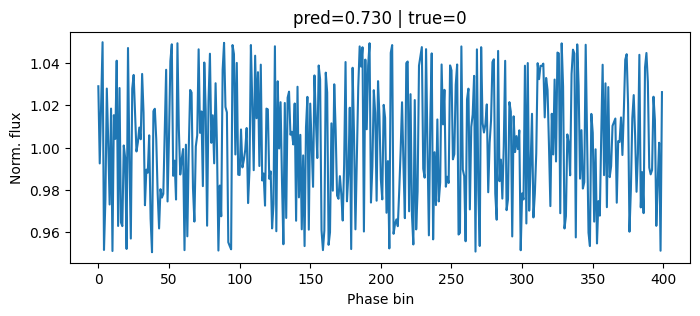

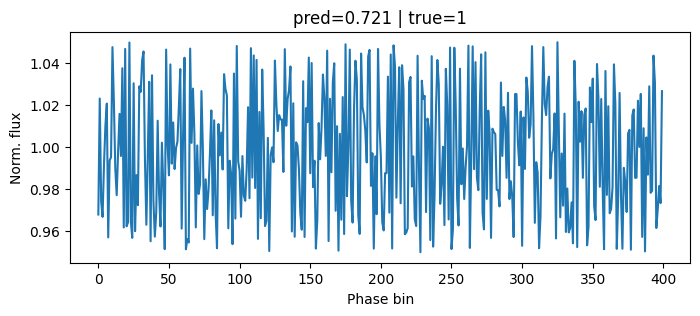

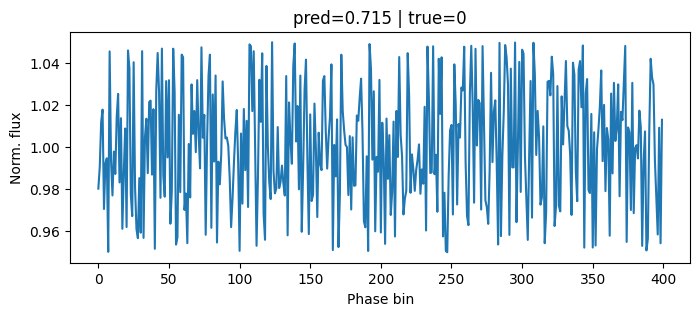

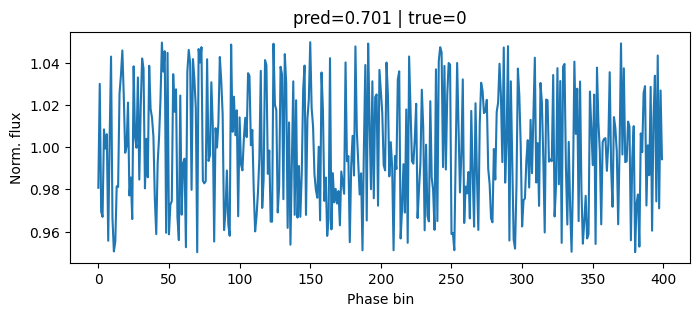

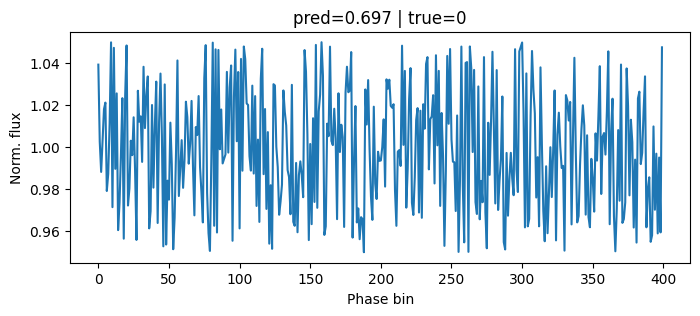

Model saved to cnn_kepler_200_v2.keras


In [6]:
# ── Evaluation ────────────────────────────────────────────────────────
y_pred  = model.predict(X_test).ravel()
y_class = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_class, target_names=['False Positive', 'Confirmed']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}')

# ROC + PR curves
fpr, tpr, _      = roc_curve(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
roc_auc          = auc(fpr, tpr)
pr_auc           = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC AUC={roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()
axes[1].plot(recall, precision, label=f'PR AUC={pr_auc:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)

# Confusion matrix
fig, ax = plt.subplots()
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_class),
    display_labels=['False Positive', 'Confirmed']
).plot(ax=ax, cmap='Blues')
plt.show()
plt.close(fig)

# Top-6 most confident planet predictions
for i in np.argsort(y_pred)[-6:][::-1]:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(X_test[i].squeeze())
    ax.set(title=f'pred={y_pred[i]:.3f} | true={y_test[i]}',
           xlabel='Phase bin', ylabel='Norm. flux')
    plt.show()
    plt.close(fig)

# ── Save model ────────────────────────────────────────────────────────
# NOTE: kepler_200_dataset.npz is NOT re-saved here.
# It contains the original pre-split arrays from process_data.py.
# Re-saving would overwrite it with the post-val-split X_train (smaller),
# corrupting the dataset for future runs.
model.save('cnn_kepler_200_v2.keras')
print('Model saved to cnn_kepler_200_v2.keras')
